Data Collection

In [2]:
queries = {
    "Agriculture": "farm",
    "Mining": "mining",
    "Manufacturing": "manufacturing",
    "Energy": "energy",
    "Construction": "construction",
    "Retail": "retail",
    "Information & Communication": "software",
    "Finance": "finance",
    "Real Estate": "property",
    "Professional Services": "consulting"
}

In [3]:
import requests
import time

API_KEY = "bb873cea-13da-461d-9174-0838e66d4889"

company_numbers = []

for industry, query in queries.items():

    print(f"\nCollecting for: {industry}")

    start_index = 0

    while start_index < 200:   # ~200 per industry

        url = f"https://api.company-information.service.gov.uk/search/companies?q={query}&items_per_page=50&start_index={start_index}"

        response = requests.get(url, auth=(API_KEY, ""))

        if response.status_code != 200:
            break

        data = response.json()

        for item in data.get("items", []):

            number = item.get("company_number")

            if number and number not in company_numbers:
                company_numbers.append(number)

        start_index += 50
        time.sleep(0.2)

print("Total companies collected:", len(company_numbers))











Total companies collected: 2000


In [4]:
company_data = []

for i, company in enumerate(company_numbers):

    print(f"Company {i+1}/{len(company_numbers)}")

    url = f"https://api.company-information.service.gov.uk/company/{company}"

    response = requests.get(url, auth=(API_KEY, ""))

    if response.status_code == 200:

        data = response.json()

        company_data.append({
            "company_number": company,
            "sic_codes": data.get("sic_codes")
        })

    time.sleep(0.2)

Company 1/2000
Company 2/2000
Company 3/2000
Company 4/2000
Company 5/2000
Company 6/2000
Company 7/2000
Company 8/2000
Company 9/2000
Company 10/2000
Company 11/2000
Company 12/2000
Company 13/2000
Company 14/2000
Company 15/2000
Company 16/2000
Company 17/2000
Company 18/2000
Company 19/2000
Company 20/2000
Company 21/2000
Company 22/2000
Company 23/2000
Company 24/2000
Company 25/2000
Company 26/2000
Company 27/2000
Company 28/2000
Company 29/2000
Company 30/2000
Company 31/2000
Company 32/2000
Company 33/2000
Company 34/2000
Company 35/2000
Company 36/2000
Company 37/2000
Company 38/2000
Company 39/2000
Company 40/2000
Company 41/2000
Company 42/2000
Company 43/2000
Company 44/2000
Company 45/2000
Company 46/2000
Company 47/2000
Company 48/2000
Company 49/2000
Company 50/2000
Company 51/2000
Company 52/2000
Company 53/2000
Company 54/2000
Company 55/2000
Company 56/2000
Company 57/2000
Company 58/2000
Company 59/2000
Company 60/2000
Company 61/2000
Company 62/2000
Company 63/2000
C

In [5]:
officer_data = []

for i, company in enumerate(company_numbers):

    print(f"Officers {i+1}/{len(company_numbers)}")

    url = f"https://api.company-information.service.gov.uk/company/{company}/officers"

    response = requests.get(url, auth=(API_KEY, ""))

    if response.status_code == 200:

        data = response.json()

        for officer in data.get("items", []):

            if officer.get("officer_role") == "director":

                officer_data.append({
                    "company_number": company,
                    "name": officer.get("name"),
                    "nationality": officer.get("nationality")
                })

    time.sleep(0.2)

Officers 1/2000
Officers 2/2000
Officers 3/2000
Officers 4/2000
Officers 5/2000
Officers 6/2000
Officers 7/2000
Officers 8/2000
Officers 9/2000
Officers 10/2000
Officers 11/2000
Officers 12/2000
Officers 13/2000
Officers 14/2000
Officers 15/2000
Officers 16/2000
Officers 17/2000
Officers 18/2000
Officers 19/2000
Officers 20/2000
Officers 21/2000
Officers 22/2000
Officers 23/2000
Officers 24/2000
Officers 25/2000
Officers 26/2000
Officers 27/2000
Officers 28/2000
Officers 29/2000
Officers 30/2000
Officers 31/2000
Officers 32/2000
Officers 33/2000
Officers 34/2000
Officers 35/2000
Officers 36/2000
Officers 37/2000
Officers 38/2000
Officers 39/2000
Officers 40/2000
Officers 41/2000
Officers 42/2000
Officers 43/2000
Officers 44/2000
Officers 45/2000
Officers 46/2000
Officers 47/2000
Officers 48/2000
Officers 49/2000
Officers 50/2000
Officers 51/2000
Officers 52/2000
Officers 53/2000
Officers 54/2000
Officers 55/2000
Officers 56/2000
Officers 57/2000
Officers 58/2000
Officers 59/2000
Office

Data Joining

In [280]:
import pandas as pd

df_officers = pd.DataFrame(officer_data)
df_companies = pd.DataFrame(company_data)

In [281]:
df = df_officers.merge(df_companies, on="company_number", how="left")

Data Cleaning

In [282]:
print(f"Total director records: {len(df)}")
print(f"Null nationalities: {df['nationality'].isna().sum()}")
print(f"Unique raw values: {df['nationality'].nunique()}")
print()
print(df["nationality"].value_counts().to_string())


Total director records: 4760
Null nationalities: 1
Unique raw values: 121

nationality
British                                3611
English                                  94
Irish                                    89
American                                 75
Filipino                                 62
Romanian                                 57
German                                   56
French                                   54
Indian                                   45
Italian                                  45
Polish                                   40
Australian                               40
Pakistani                                37
Scottish                                 29
South African                            26
Spanish                                  25
Russian                                  19
Canadian                                 17
Hungarian                                15
Welsh                                    14
Belgian                          

In [283]:
# Lowercase and strip whitespace
df["nationality_normalized"] = df["nationality"].str.lower().str.strip()

# For multiple nationalities, take the first only
def split_compound(value):
    if pd.isna(value):
        return value
    for sep in [",", ";", "/", ", "]:
        if sep in value:
            return value.split(sep)[0].strip()
    return value

df["nationality_normalized"] = df["nationality_normalized"].apply(split_compound)


In [284]:
nationality_map = {
      "english": "british",
      "scottish": "british",
      "welsh": "british",
      "northern irish": "british",
      "united kingdom": "british",
      "uk": "british",
      "united states": "american",
      "usa": "american",
      "us": "american",
      "ireland": "irish",
      "netherlands": "dutch",
      "pakistan": "pakistani",
      "canada": "canadian",
      "cyprus": "cypriot",
      "venezuela": "venezuelan",
      "seychelles": "seychellois",
        }

df["nationality_clean"] = df["nationality_normalized"].map(nationality_map)

In [ ]:
canonical = [
    "british", "irish", "american", "french", "german", "italian",
    "spanish", "polish", "romanian", "indian", "pakistani", "chinese",
    "australian", "canadian", "south african", "nigerian", "filipino",
    "dutch", "belgian", "hungarian", "russian", "ukrainian", "turkish",
    "brazilian", "japanese", "greek", "portuguese", "swedish", "danish",
    "norwegian", "finnish", "czech", "slovak", "bulgarian", "latvian",
    "lithuanian", "estonian", "austrian", "swiss", "egyptian", "moroccan",
    "algerian", "kenyan", "ghanaian", "zimbabwean", "bangladeshi",
    "sri lankan", "malaysian", "malawian", "cypriot", "lebanese", "israeli",
    "iranian", "iraqi", "saudi arabian", "emirati", "mexican",
    "chilean", "peruvian", "jamaican", "nepalese", "albanian",
    "new zealander", "jordanian", "senegalese", "ethiopian",
    "dominican", "guyanese", "gabonese", "sudanese", "afghan",
    "kazakh", "belizean", "luxembourger", "maltese", "yemeni",
    "singaporean", "thai", "korean", "taiwanese", "colombian",
    "argentine", "ecuadorian", "trinidadian", "barbadian",
  ]

In [286]:
from rapidfuzz import process, fuzz

# Only fuzzy match values that weren't handled by the nationality map
remaining = df.loc[df["nationality_clean"].isna(), "nationality_normalized"].dropna().unique()
print(f"Values to fuzzy match: {len(remaining)}")

fuzzy_map = {}
unmatched = []

for raw in remaining:
    # Exact match against canonical list (free check before fuzzy)
    if raw in canonical:
        fuzzy_map[raw] = raw
        continue

    result = process.extractOne(
        raw,
        canonical,
        scorer=fuzz.ratio,
        score_cutoff=80
    )

    if result:
        match, score, _ = result
        fuzzy_map[raw] = match
    else:
        unmatched.append(raw)


Values to fuzzy match: 89


In [287]:
# Show non-exact fuzzy matches for review
fuzzy_corrections = {k: v for k, v in fuzzy_map.items() if k != v}

print("Fuzzy corrections")
for raw, matched in sorted(fuzzy_corrections.items()):
    print(f"  {raw:40s} → {matched}")

print(f"\nUnmatched ({len(unmatched)}) ")
for val in sorted(unmatched):
    count = (df["nationality_normalized"] == val).sum()
    print(f"  {val:40s} ({count} rows)")


Fuzzy corrections
  austrialian                              → australian
  brittish                                 → british
  luxemburger                              → luxembourger
  ukranian                                 → ukrainian

Unmatched (10) 
  brisith                                  (1 rows)
  british (dual citizen south africa)      (1 rows)
  citizen of bosnia and herzegovina        (1 rows)
  citizen of seychelles                    (5 rows)
  citizen of vanuatu                       (1 rows)
  hong konger                              (1 rows)
  kittitian                                (1 rows)
  other                                    (1 rows)
  seychellois                              (1 rows)
  south african and ir                     (1 rows)


Data Cleaning

In [288]:
print(df["nationality"].value_counts().to_string())

nationality
British                                3611
English                                  94
Irish                                    89
American                                 75
Filipino                                 62
Romanian                                 57
German                                   56
French                                   54
Indian                                   45
Italian                                  45
Polish                                   40
Australian                               40
Pakistani                                37
Scottish                                 29
South African                            26
Spanish                                  25
Russian                                  19
Canadian                                 17
Hungarian                                15
Welsh                                    14
Belgian                                  13
Lithuanian                               13
Ukrainian           

In [289]:
df['nationality_normalized'] = (df['nationality']).str.strip().str.lower()

In [290]:
mapping = {
    "english": "british", 'scottish': 'british', 'welsh': 'british', 'brtish': 'british', 'brittish': 'british','south african,irish':'british', 'irish,british':'irish', 'british,irish':'british', 'ireland':'irish','australian,portuguese':'australian','british,canadian':'british', 'british,polish':'british','australian,polish':'australian','cyprus':'cypriot', 'venezuela':'venezuelan','romanian,moldovan':'romanian', 'british,american':'american','brisith':'british','united states':'american','seychellois':'seychelles','austrialian':'australian','british (dual citizen south africa)':'british','south african and ir':'south african', 'italian,south african':'italian','canada':'canadian','british,pakistani':'british', 'italian,british':'italian','british,ghanaian':'british','pakistan':'pakistani','british,romanian':'british','south african,french':'south african','british,south africa':'british','united kingdom':'british', 'usa':'american', 'us':'american','uk':'british','nigerien':'nigerian', 'city of seychelles':'seychelles', 'usa':'american','new zealand':'new zealander'}

df['nationality_clean'] = df['nationality_normalized'].replace(mapping)

In [291]:
df['nationality_clean'].value_counts()

nationality_clean
british               3768
irish                   91
american                84
filipino                62
romanian                58
                      ... 
luxemburger              1
jamaican                 1
luxembourger             1
citizen of vanuatu       1
finnish                  1
Name: count, Length: 89, dtype: int64

Matching SIC codes to Industry

In [292]:
df["sic_code"] = df["sic_codes"].str[0] 
df["sic_2"] = df["sic_code"].str[:2]

In [293]:
sic_to_industry = {

    "01": "Agriculture",
    "02": "Agriculture",
    "03": "Agriculture",

    "05": "Mining",
    "06": "Mining",
    "07": "Mining",
    "08": "Mining",

    "10": "Manufacturing",
    "11": "Manufacturing",
    "12": "Manufacturing",
    "13": "Manufacturing",

    "35": "Energy",

    "41": "Construction",
    "42": "Construction",
    "43": "Construction",

    "45": "Retail",
    "46": "Retail",
    "47": "Retail",

    "58": "Information & Communication",
    "59": "Information & Communication",
    "60": "Information & Communication",
    "61": "Information & Communication",
    "62": "Information & Communication",
    "63": "Information & Communication",

    "64": "Finance",
    "65": "Finance",
    "66": "Finance",

    "68": "Real Estate",

    "69": "Professional Services",
    "70": "Professional Services",
    "71": "Professional Services",
    "72": "Professional Services",
    "73": "Professional Services",
    "74": "Professional Services"
}

In [294]:
df["industry"] = df["sic_2"].map(sic_to_industry)
df["industry"] = df["industry"].fillna("Other")

In [295]:
df["industry"].value_counts()

# Question - are all industry groups present? 

industry
Other                          1625
Professional Services           962
Information & Communication     587
Retail                          412
Construction                    385
Finance                         332
Real Estate                     295
Mining                           87
Agriculture                      31
Energy                           28
Manufacturing                    16
Name: count, dtype: int64

Core analysis

In [296]:
df_non_british = df[df["nationality_clean"] != "british"]

In [297]:
top_nationalities = (
    df_non_british
    .groupby(["industry", "nationality_clean"])
    .size()
    .reset_index(name="count")
)

In [298]:
top_by_industry = (
    top_nationalities
    .sort_values(["industry", "count"], ascending=[True, False])
    .groupby("industry")
    .first()
    .reset_index()
)

Visualise

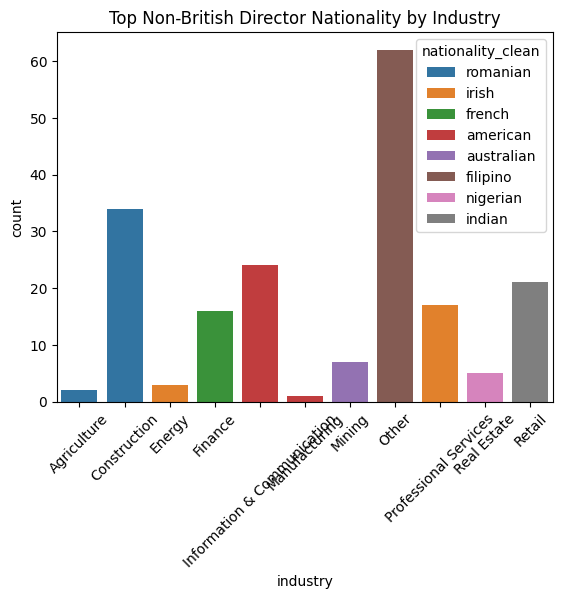

In [299]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=top_by_industry,
    x="industry",
    y="count",
    hue="nationality_clean"
)

plt.xticks(rotation=45)
plt.title("Top Non-British Director Nationality by Industry")

plt.show()

Interpretation
    - E.g. finance shows a lot of Americans, etc 


Predictive modelling 
    - Given a director's nationality (non-British), which industry are they most likely to belong to? 

In [300]:
df_model = df.dropna(subset=["nationality_clean", "industry"])

In [301]:
industry_counts = df_model["industry"].value_counts()

valid_industries = industry_counts[industry_counts > 20].index

df_model = df_model[df_model["industry"].isin(valid_industries)]

In [302]:
# X (features)

X = df_model[["nationality_clean"]]

# y (target)

y = df_model["industry"]   


In [303]:
X_encoded = pd.get_dummies(X)


In [304]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [305]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100,random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [306]:
# Accuracy

accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy    )

# Classification report

from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

Accuracy: 0.3561643835616438
                             precision    recall  f1-score   support

                Agriculture       0.00      0.00      0.00         6
               Construction       0.58      0.09      0.16        76
                     Energy       0.00      0.00      0.00         5
                    Finance       0.00      0.00      0.00        61
Information & Communication       0.29      0.02      0.03       115
                     Mining       0.00      0.00      0.00        23
                      Other       0.36      0.95      0.52       335
      Professional Services       0.33      0.01      0.02       186
                Real Estate       0.00      0.00      0.00        64
                     Retail       0.37      0.13      0.19        78

                   accuracy                           0.36       949
                  macro avg       0.19      0.12      0.09       949
               weighted avg       0.30      0.36      0.22       949



c:\Users\clark\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\clark\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\clark\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [307]:
# Importance of features

feature_importance = pd.DataFrame({"feature": X_encoded.columns, "importance": model.feature_importances_}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
29,nationality_clean_filipino,0.156395
70,nationality_clean_romanian,0.088676
11,nationality_clean_british,0.062225
38,nationality_clean_indian,0.036806
14,nationality_clean_canadian,0.023505
30,nationality_clean_french,0.023365
52,nationality_clean_lithuanian,0.018858
62,nationality_clean_nigerian,0.018263
3,nationality_clean_american,0.017232
41,nationality_clean_irish,0.015938


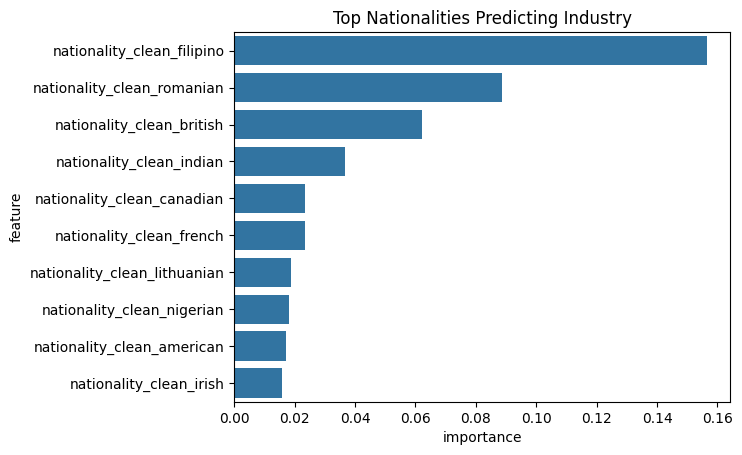

In [308]:
top_features = feature_importance.head(10)

sns.barplot(data=top_features, x="importance", y="feature")

plt.title("Top Nationalities Predicting Industry")
plt.show()